In [1]:
pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('sales_data.csv')

# Display first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Basic information
print("\n--- Data Info ---")
print(df.info())

--- First 5 Rows ---


,CustomerID,Region,Sales,Discount,Date,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,SatisfactionScore,ProductCategory
0,1001,East,21708.779879,NaN,2024-02-27 03:21:48.108108104,164,16,0,VIP,Online,Credit Card,3,Electronics
1,1002,West,29380.854196,5.0,2024-05-09 22:40:43.243243240,156,22,0,New,In-Store,Bank Transfer,6,Sports
2,1003,North,24752.119191,15.0,2024-05-01 00:05:45.945945944,192,85,0,New,In-Store,Credit Card,2,Health & Beauty
3,1004,East,17115.481722,5.0,2024-08-25 20:59:49.189189184,198,54,0,Returning,Direct,Cash,10,Sports
4,1005,East,15507.926643,NaN,2024-05-31 15:48:28.108108104,139,21,0,New,In-Store,Credit Card,1,Sports



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   int64  
 1   Region             970 non-null    object 
 2   Sales              950 non-null    float64
 3   Discount           723 non-null    float64
 4   Date               1000 non-null   object 
 5   ProductID          1000 non-null   int64  
 6   Quantity           1000 non-null   int64  
 7   Return             1000 non-null   int64  
 8   CustomerType       1000 non-null   object 
 9   SalesChannel       1000 non-null   object 
 10  PaymentMethod      1000 non-null   object 
 11  SatisfactionScore  1000 non-null   int64  
 12  ProductCategory    1000 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB
None


In [3]:
# Define business relevance based on column names
business_relevance = {
    'CustomerID': 'Unique identifier for each customer.',
    'Region': 'Geographical region of the sale (North, South, East, West).',
    'Sales': 'Total revenue generated from the transaction.',
    'Discount': 'Discount percentage applied to the sale.',
    'Date': 'Timestamp of when the transaction occurred.',
    'ProductID': 'Unique identifier for the product sold.',
    'Quantity': 'Number of units sold in the transaction.',
    'Return': 'Indicator if the product was returned (1) or not (0).',
    'CustomerType': 'Classification of customer (VIP, New, Returning).',
    'SalesChannel': 'Where the sale happened (Online, In-Store, Direct).',
    'PaymentMethod': 'Method used for payment (Cash, Card, etc.).',
    'SatisfactionScore': 'Customer satisfaction rating (1-10).',
    'ProductCategory': 'Category of the product (Electronics, Sports, etc.).'
}

# Generate Data Dictionary DataFrame
data_dict = pd.DataFrame({
    'Column_Name': df.columns,
    'Data_Type': df.dtypes.values,
    'Non_Null_Count': df.count().values,
    'Missing_Values': df.isnull().sum().values,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Sample_Value': [str(df[col].dropna().iloc[0]) if not df[col].empty else 'N/A' for col in df.columns],
    'Business_Relevance': [business_relevance.get(col, 'General data field') for col in df.columns]
})

# Save to CSV for GitHub Deliverable
data_dict.to_csv('01_Data_Dictionary.csv', index=False)
print("\nData Dictionary saved as '01_Data_Dictionary.csv'")
display(data_dict)


Data Dictionary saved as '01_Data_Dictionary.csv'


,Column_Name,Data_Type,Non_Null_Count,Missing_Values,Unique_Values,Sample_Value,Business_Relevance
0,CustomerID,int64,1000,0,1000,1001,Unique identifier for each customer.
1,Region,object,970,30,4,East,"Geographical region of the sale (North, South,..."
2,Sales,float64,950,50,950,21708.7798788858,Total revenue generated from the transaction.
3,Discount,float64,723,277,3,5.0,Discount percentage applied to the sale.
4,Date,object,1000,0,637,2024-02-27 03:21:48.108108104,Timestamp of when the transaction occurred.
5,ProductID,int64,1000,0,100,164,Unique identifier for the product sold.
6,Quantity,int64,1000,0,99,16,Number of units sold in the transaction.
7,Return,int64,1000,0,2,0,Indicator if the product was returned (1) or n...
8,CustomerType,object,1000,0,3,VIP,"Classification of customer (VIP, New, Returning)."
9,SalesChannel,object,1000,0,3,Online,"Where the sale happened (Online, In-Store, Dir..."


C:\Users\malli\AppData\Local\Temp\ipykernel_9384\3790534690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='viridis')


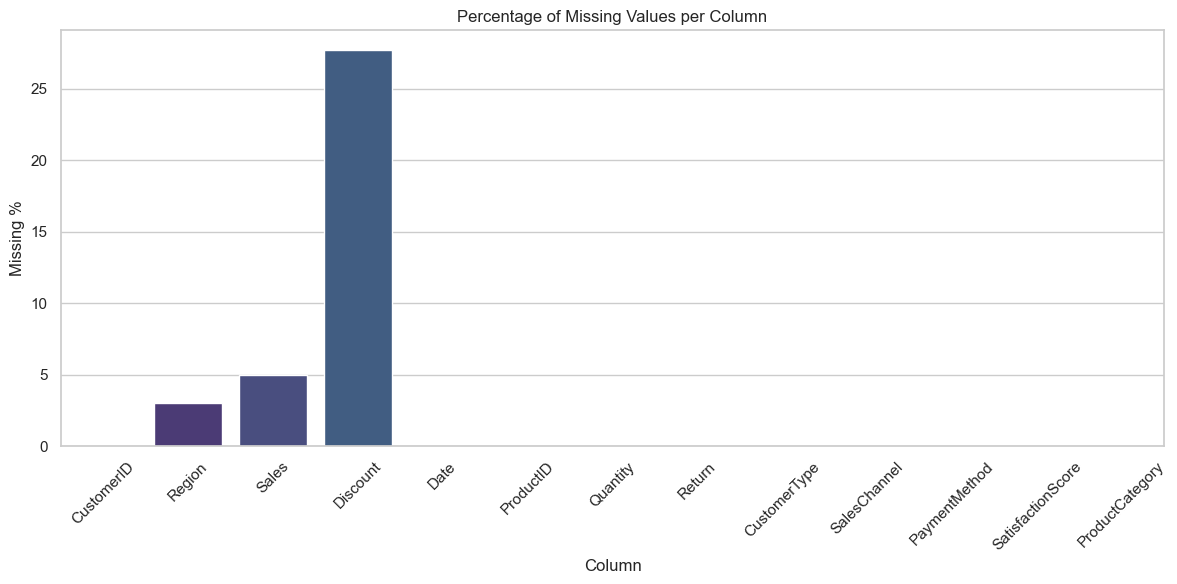

--- Missing Value Report ---
Region       3.0
Sales        5.0
Discount    27.7
dtype: float64


In [4]:
# Calculate missing percentages
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

# Plot Missing Values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='viridis')
plt.title('Percentage of Missing Values per Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('02_Missing_Values_Plot.png') # Save for GitHub/Video
plt.show()

print("--- Missing Value Report ---")
print(missing_percent[missing_percent > 0])

In [5]:
duplicates = df.duplicated().sum()
print(f"\nTotal Exact Duplicate Rows: {duplicates}")

# Check duplicates based on Transaction uniqueness (e.g., CustomerID + Date + ProductID)
# Note: Since there is no TransactionID, we check combination of keys
key_cols = ['CustomerID', 'Date', 'ProductID']
dup_keys = df.duplicated(subset=key_cols, keep=False).sum()
print(f"Potential Duplicate Transactions (Same Customer, Date, Product): {dup_keys}")


Total Exact Duplicate Rows: 0
Potential Duplicate Transactions (Same Customer, Date, Product): 0


In [6]:
categorical_cols = ['Region', 'CustomerType', 'SalesChannel', 'PaymentMethod', 'ProductCategory']

print("\n--- Unique Values Check (Looking for inconsistencies) ---")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


--- Unique Values Check (Looking for inconsistencies) ---

Region:
Region
West     269
North    253
East     224
South    224
Name: count, dtype: int64

CustomerType:
CustomerType
Returning    365
New          324
VIP          311
Name: count, dtype: int64

SalesChannel:
SalesChannel
In-Store    339
Online      333
Direct      328
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Bank Transfer    345
Cash             338
Credit Card      317
Name: count, dtype: int64

ProductCategory:
ProductCategory
Books              160
Health & Beauty    155
Toys               146
Sports             138
Electronics        136
Home & Kitchen     133
Clothing           132
Name: count, dtype: int64


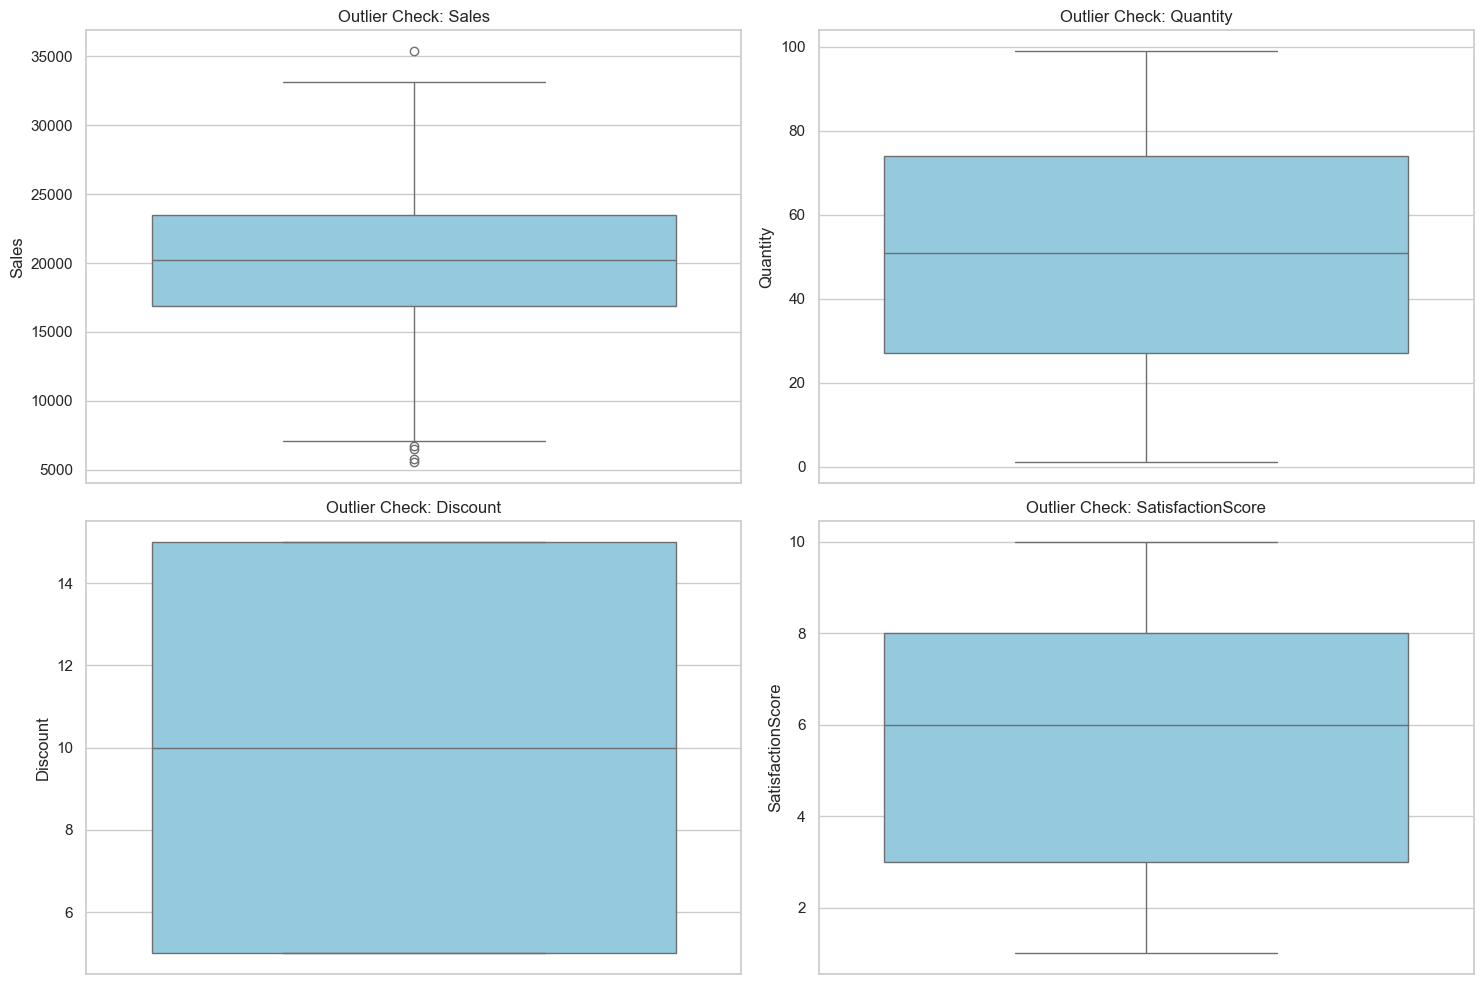

In [7]:
# Boxplot for Numerical Columns
num_cols = ['Sales', 'Quantity', 'Discount', 'SatisfactionScore']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outlier Check: {col}')
    plt.tight_layout()

plt.savefig('02_Outlier_Boxplots.png') # Save for GitHub/Video
plt.show()

In [8]:
# 1. Region: Fill with 'Unknown'
df['Region'] = df['Region'].fillna('Unknown')

# 2. Discount: Fill with 0 (No discount)
df['Discount'] = df['Discount'].fillna(0)

# 3. Sales: Impute with Median per Category
# Calculate median sales per category
median_sales = df.groupby('ProductCategory')['Sales'].transform('median')
# Fill missing sales with the category median
df['Sales'] = df['Sales'].fillna(median_sales)

# If any sales are still null (category had all nulls), fill with global median
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

print(f"Remaining Missing Values:\n{df.isnull().sum()}")

Remaining Missing Values:
CustomerID           0
Region               0
Sales                0
Discount             0
Date                 0
ProductID            0
Quantity             0
Return               0
CustomerType         0
SalesChannel         0
PaymentMethod        0
SatisfactionScore    0
ProductCategory      0
dtype: int64


In [9]:
# Convert to DateTime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Verify conversion
print(f"\nDate Column Type: {df['Date'].dtype}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")


Date Column Type: datetime64[ns]
Date Range: 2023-01-01 00:00:00 to 2024-09-30 00:00:00


In [10]:
# 1. Extract Date Components
df['TransactionYear'] = df['Date'].dt.year
df['TransactionMonth'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()

# 2. Calculate Net Sales (Assuming Discount is percentage)
# Formula: Sales * (1 - (Discount / 100))
df['NetSales'] = df['Sales'] * (1 - (df['Discount'] / 100))

# 3. High Value Transaction Flag (Business Logic: Top 10% of Sales)
threshold = df['Sales'].quantile(0.90)
df['IsHighValue'] = np.where(df['Sales'] >= threshold, 1, 0)

print("\n--- New Features Created ---")
display(df[['Date', 'TransactionMonth', 'DayOfWeek', 'Sales', 'Discount', 'NetSales', 'IsHighValue']].head())


--- New Features Created ---


,Date,TransactionMonth,DayOfWeek,Sales,Discount,NetSales,IsHighValue
0,2024-02-27 03:21:48.108108104,2,Tuesday,21708.779879,0.0,21708.779879,0
1,2024-05-09 22:40:43.243243240,5,Thursday,29380.854196,5.0,27911.811486,1
2,2024-05-01 00:05:45.945945944,5,Wednesday,24752.119191,15.0,21039.301312,0
3,2024-08-25 20:59:49.189189184,8,Sunday,17115.481722,5.0,16259.707636,0
4,2024-05-31 15:48:28.108108104,5,Friday,15507.926643,0.0,15507.926643,0


In [11]:
# Cap Sales at 95th percentile
upper_limit = df['Sales'].quantile(0.95)
df['Sales_Capped'] = np.where(df['Sales'] > upper_limit, upper_limit, df['Sales'])

print(f"\nOriginal Max Sales: {df['Sales'].max()}")
print(f"Capped Max Sales: {df['Sales_Capped'].max()}")


Original Max Sales: 35394.40404227619
Capped Max Sales: 28639.821008769686


In [12]:
# Define final columns to keep
final_columns = [
    'CustomerID', 'Region', 'Sales', 'NetSales', 'Discount', 
    'Date', 'TransactionYear', 'TransactionMonth', 'DayOfWeek',
    'ProductID', 'Quantity', 'Return', 'CustomerType', 
    'SalesChannel', 'PaymentMethod', 'SatisfactionScore', 
    'ProductCategory', 'IsHighValue'
]

# Select columns
df_clean = df[final_columns]

# Save to CSV for GitHub Deliverable
df_clean.to_csv('03_Cleaned_Sales_Data.csv', index=False)
print("\n✅ Cleaned dataset saved as '03_Cleaned_Sales_Data.csv'")
display(df_clean.head())


✅ Cleaned dataset saved as '03_Cleaned_Sales_Data.csv'


,CustomerID,Region,Sales,NetSales,Discount,Date,TransactionYear,TransactionMonth,DayOfWeek,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,SatisfactionScore,ProductCategory,IsHighValue
0,1001,East,21708.779879,21708.779879,0.0,2024-02-27 03:21:48.108108104,2024,2,Tuesday,164,16,0,VIP,Online,Credit Card,3,Electronics,0
1,1002,West,29380.854196,27911.811486,5.0,2024-05-09 22:40:43.243243240,2024,5,Thursday,156,22,0,New,In-Store,Bank Transfer,6,Sports,1
2,1003,North,24752.119191,21039.301312,15.0,2024-05-01 00:05:45.945945944,2024,5,Wednesday,192,85,0,New,In-Store,Credit Card,2,Health & Beauty,0
3,1004,East,17115.481722,16259.707636,5.0,2024-08-25 20:59:49.189189184,2024,8,Sunday,198,54,0,Returning,Direct,Cash,10,Sports,0
4,1005,East,15507.926643,15507.926643,0.0,2024-05-31 15:48:28.108108104,2024,5,Friday,139,21,0,New,In-Store,Credit Card,1,Sports,0
